Exercise 1

In [1]:
import math, random, time, statistics
from MP2_exercise import estimate_pi_serial

if __name__ == '__main__':
    random.seed(42)
    num_samples = 10000000
    times = []
    pies = []
    for _ in range(3):
        t0 = time.perf_counter()
        pi_estimate = estimate_pi_serial(num_samples)
        times.append(time.perf_counter() - t0)
        pies.append(pi_estimate)
        print(f"Run {_+1}:")
        print(f"pi estimate: {pi_estimate:.6f}")
        print(f"error: {abs(pi_estimate - math.pi):.6f}")
        print(f"Time: {time.perf_counter() - t0:.3f} s")

    t_serial = statistics.median(times)
    print("averages:")
    print(f"pi estimate: {statistics.median(pies):.6f} (error: {abs(statistics.median(pies)-math.pi):.6f})")
    print(f"Serial time: {t_serial:.3f}s")

Run 1:
pi estimate: 3.142310
error: 0.000717
Time: 1.021 s
Run 2:
pi estimate: 3.141866
error: 0.000273
Time: 1.008 s
Run 3:
pi estimate: 3.141505
error: 0.000087
Time: 1.007 s
averages:
pi estimate: 3.141866 (error: 0.000273)
Serial time: 1.008s


How accurate is the estimate? On average: 0.000273 with 3 runs and 10kk samples  
Run several times — does it vary? yes  
What is the serial time? 1.036seconds This will be your speedup denominator in E3.

In [2]:
from MP2_exercise import estimate_pi_parallel
import os, time, statistics, random

if __name__ == '__main__':
    random.seed(42)
    num_samples = 10_000_000
    for num_proc in range(1, os.cpu_count() + 1):
        times = []
        for _ in range(3):
            t0 = time.perf_counter()
            pi_est = estimate_pi_parallel(num_samples, num_proc)
            times.append(time.perf_counter() - t0)
        t = statistics.median(times)
        print(f"{num_proc:2d} workers: {t:.3f}s pi={pi_est:.6f}")

 1 workers: 1.115s pi=3.142418
 2 workers: 0.595s pi=3.141365
 3 workers: 0.538s pi=3.141306
 4 workers: 0.417s pi=3.142013
 5 workers: 0.340s pi=3.140715
 6 workers: 0.303s pi=3.141961
 7 workers: 0.392s pi=3.142773
 8 workers: 0.366s pi=3.142415


Do all worker counts give the same ˆπ? Why or why not? Monte Carlo uses random sampling  
At which count do you first see a meaningful speedup? from 1 to 2 workers halves the runtume, afterwards the gain is decreasing

1. At which worker count p∗is speedup maximum?  
$$S_6=1.061/0.239=4.44$$

2. Does speedup plateau or drop beyond p∗? Why?   
yes, at S_5<. Probably parallel overhead - process spawning, inter-process communication, task distribution, result collection, scheduling costs. Further it aligns with Amdahl's law.

3. Back-solve implied serial fraction: s = 1/Sp∗−1/p∗ / 1−1/p∗ — what fraction of time is effectively serial (IPC overhead + spawning)?  
$$s = ((1/4.44)-(1/6))/1-(1/6)=0.07$$

4. Mac M1/M2/M3 users: do you see a slope change near worker 8 (E-cores)?  
Yes, apparently M chips use performance cores and efficiency cores


 line_profiler: mandelbrot (naive Python) 

Timer unit: 1e-09 s

Total time: 13.1542 s
File: /Users/niklasandersen/Documents/GitHub/NSC-mandelbrot/mandelbrot.py
Function: mandelbrot_naive at line 69

Line #      Hits         Time  Per Hit   % Time  Line Contents
    69                                           def mandelbrot_naive(width, height, max_iter, xmin, xmax, ymin, ymax):
    70         1    2908000.0 2.91e+06      0.0      img = [[0] * width for _ in range(height)]
    71                                           
    72      1025     284000.0    277.1      0.0      for y in range(height):
    73      1024     210000.0    205.1      0.0          im = ymin + (y / (height - 1)) * (ymax - ymin)
    74                                           
    75   1049600  171856000.0    163.7      1.3          for x in range(width):
    76   1048576  207851000.0    198.2      1.6              re = xmin + (x / (width - 1)) * (xmax - xmin)
    77   1048576  245158000.0    233.8      1.9     

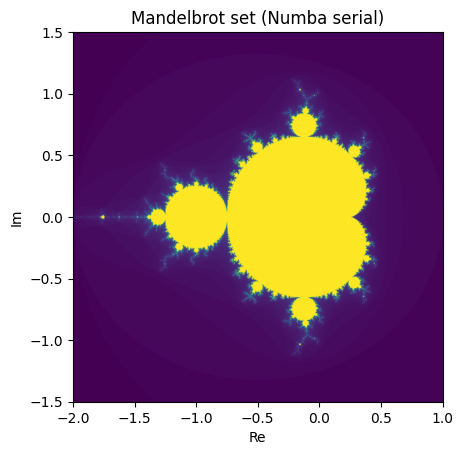

In [3]:
from mandelbrot import mandelbrot_serial
import matplotlib.pyplot as plt

grid_sizes = [1024]

max_iter = 100
xmin, xmax = -2.0, 1.0
ymin, ymax = -1.5, 1.5

width = grid_sizes[0]
height = grid_sizes[0]

warm_args = (256, 256, max_iter, xmin, xmax, ymin, ymax)
mandelbrot_serial(*warm_args)

t0 = time.perf_counter()
numba_serial = mandelbrot_serial(width, height, max_iter, xmin, xmax, ymin, ymax)
t1 = time.perf_counter()

print(f"Runtime: {t1 - t0:.6f} s")

# plotting
plt.figure()
plt.imshow(numba_serial, extent=(xmin, xmax, ymin, ymax), origin="lower")
plt.title("Mandelbrot set (Numba serial)")
plt.xlabel("Re")
plt.ylabel("Im")
plt.savefig("mandelbrot_numba_basic.png", dpi=150, bbox_inches="tight")
plt.show()